NAME: ALOK KUMAR MAVI

SEC: B, ROLL.NO.05

# LAB SHEET - 08

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

OpenCV version: 5.0.0
NumPy version: 2.1.3


In [2]:
from google.colab import files

uploaded = files.upload()

Saving video.mp4 to video.mp4


In [3]:
video_path = "video.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open the video.")
else:
    print("Video opened successfully!")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print("FPS:", fps)
    print("Total Frames:", frame_count)
    print("Resolution:", width, "x", height)

cap.release()

Video opened successfully!
FPS: 30.0
Total Frames: 60
Resolution: 2560 x 1440


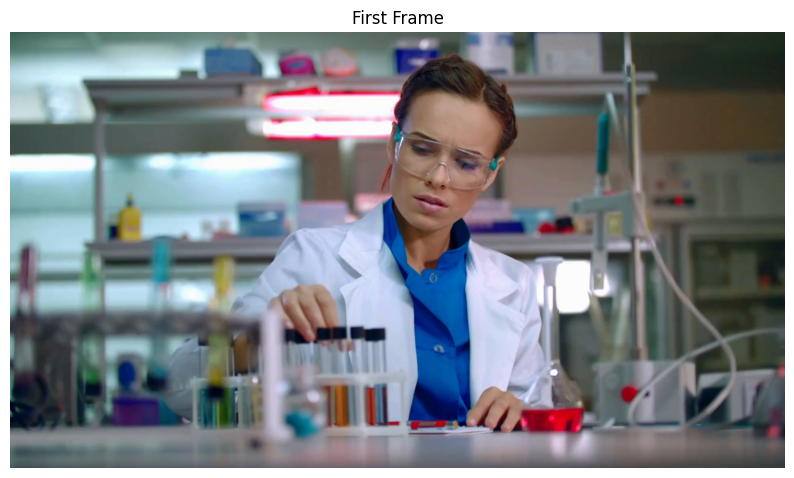

In [4]:
cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

cap.release()

if ret:
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("First Frame")
    plt.axis("off")
    plt.show()
else:
    print("Error: Could not read the first frame.")

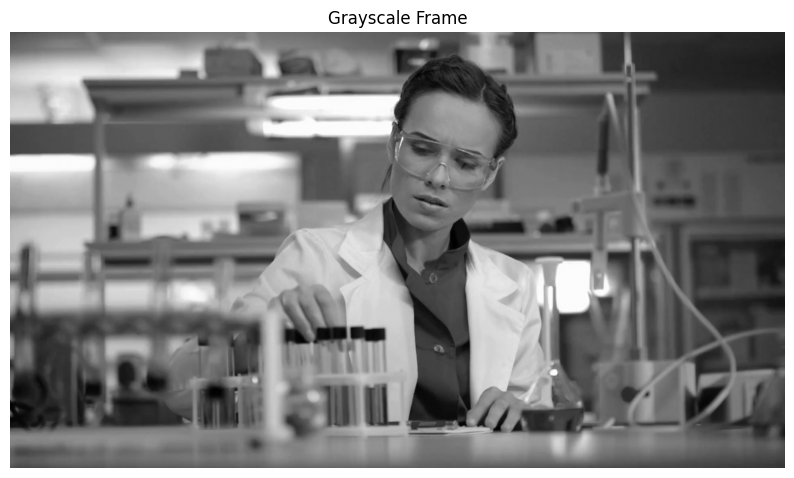

In [5]:
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Frame")
plt.axis("off")
plt.show()

In [6]:
feature_params = dict(
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

p0 = cv2.goodFeaturesToTrack(
    gray,
    mask=None,
    **feature_params
)

print("Number of detected feature points:", len(p0))

Number of detected feature points: 30


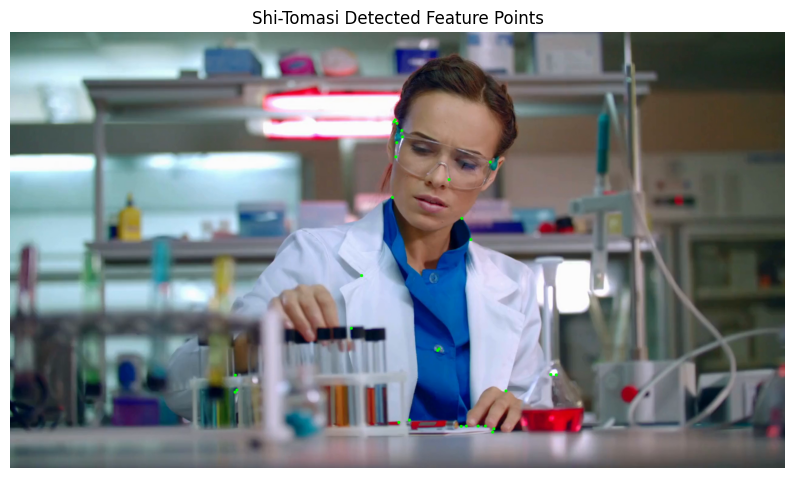

In [7]:
feature_frame = frame.copy()

for point in p0:
    x, y = point.ravel()

    cv2.circle(
        feature_frame,
        (int(x), int(y)),
        5,
        (0, 255, 0),
        -1
    )

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(feature_frame, cv2.COLOR_BGR2RGB))
plt.title("Shi-Tomasi Detected Feature Points")
plt.axis("off")
plt.show()

In [8]:
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(
        cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
        10,
        0.03
    )
)

print("Lucas-Kanade parameters initialized.")

Lucas-Kanade parameters initialized.


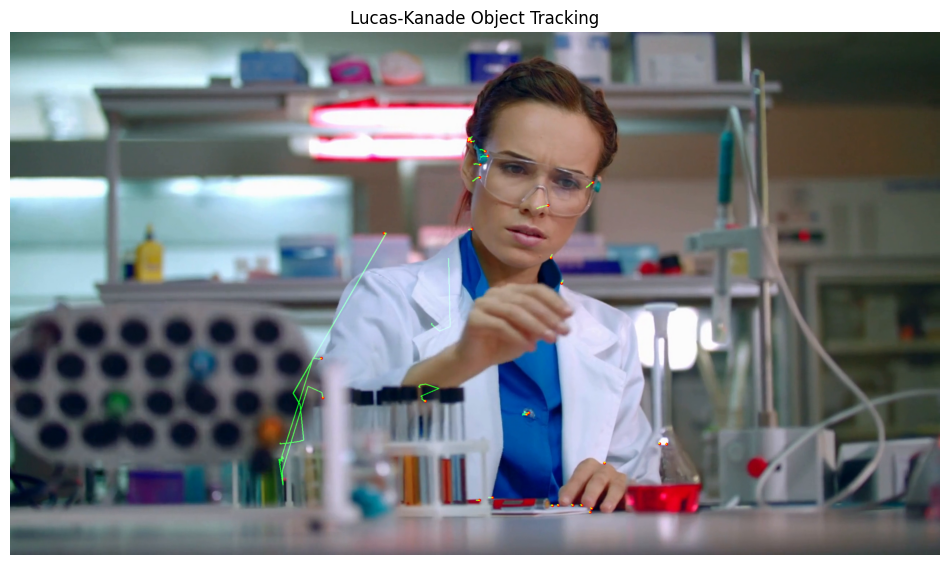

Frames processed: 30
Successfully tracked points: 29


In [9]:
# Lucas-Kanade Optical Flow Tracking

cap = cv2.VideoCapture(video_path)

ret, old_frame = cap.read()

if not ret:
    print("Error: Could not read the video.")
else:
    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

    # Detect initial feature points
    p0 = cv2.goodFeaturesToTrack(
        old_gray,
        mask=None,
        **feature_params
    )

    # Mask used to draw trajectories
    mask = np.zeros_like(old_frame)

    frame_number = 0
    tracking_results = []

    while frame_number < 30:
        ret, frame = cap.read()

        if not ret:
            break

        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Calculate Lucas-Kanade optical flow
        p1, status, error = cv2.calcOpticalFlowPyrLK(
            old_gray,
            frame_gray,
            p0,
            None,
            **lk_params
        )

        if p1 is None:
            break

        # Keep successfully tracked points
        good_new = p1[status == 1]
        good_old = p0[status == 1]

        # Calculate motion data
        displacements = good_new - good_old

        if len(displacements) > 0:
            magnitudes = np.sqrt(
                displacements[:, 0]**2 +
                displacements[:, 1]**2
            )

            average_magnitude = np.mean(magnitudes)

            tracking_results.append(average_magnitude)

        # Draw trajectories
        for new, old in zip(good_new, good_old):

            x_new, y_new = new.ravel()
            x_old, y_old = old.ravel()

            # Draw trajectory line
            mask = cv2.line(
                mask,
                (int(x_new), int(y_new)),
                (int(x_old), int(y_old)),
                (0, 255, 0),
                2
            )

            # Draw current feature point
            frame = cv2.circle(
                frame,
                (int(x_new), int(y_new)),
                4,
                (0, 0, 255),
                -1
            )

        output = cv2.add(frame, mask)

        # Show the result on the last processed frame
        if frame_number == 29:
            plt.figure(figsize=(12, 7))
            plt.imshow(
                cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
            )
            plt.title("Lucas-Kanade Object Tracking")
            plt.axis("off")
            plt.show()

        # Prepare for next frame
        old_gray = frame_gray.copy()
        p0 = good_new.reshape(-1, 1, 2)

        if len(p0) == 0:
            break

        frame_number += 1

    cap.release()

    print("Frames processed:", frame_number)
    print("Successfully tracked points:", len(p0))

In [10]:
if len(tracking_results) > 0:
    print(
        "Average displacement per frame:",
        np.mean(tracking_results)
    )

    print(
        "Maximum displacement:",
        np.max(tracking_results)
    )

    print(
        "Minimum displacement:",
        np.min(tracking_results)
    )
else:
    print("No tracking data available.")

Average displacement per frame: 2.5436907
Maximum displacement: 17.602634
Minimum displacement: 0.012954711


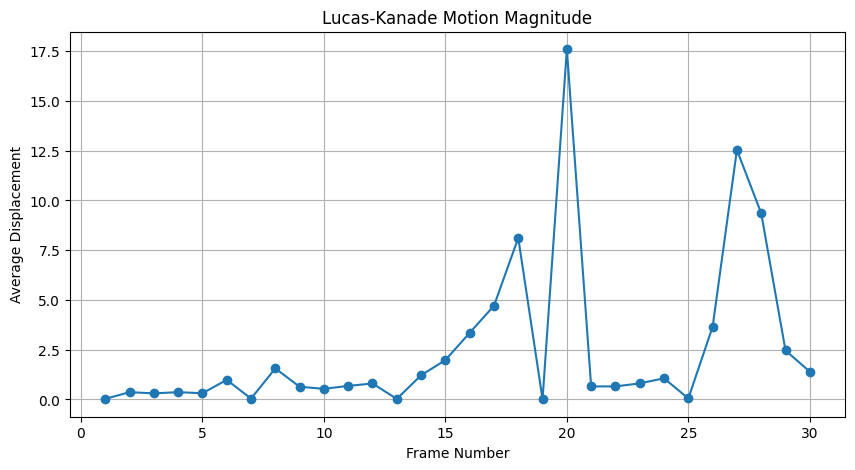

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(tracking_results) + 1),
    tracking_results,
    marker="o"
)

plt.title("Lucas-Kanade Motion Magnitude")
plt.xlabel("Frame Number")
plt.ylabel("Average Displacement")
plt.grid(True)

plt.show()

In [12]:
fps = cv2.VideoCapture(video_path).get(cv2.CAP_PROP_FPS)

if fps > 0 and len(tracking_results) > 0:
    average_speed = np.mean(tracking_results) * fps

    print("Video FPS:", fps)
    print(
        "Approximate average speed:",
        average_speed,
        "pixels/second"
    )
else:
    print("Unable to calculate speed.")

Video FPS: 30.0
Approximate average speed: 76.31072 pixels/second


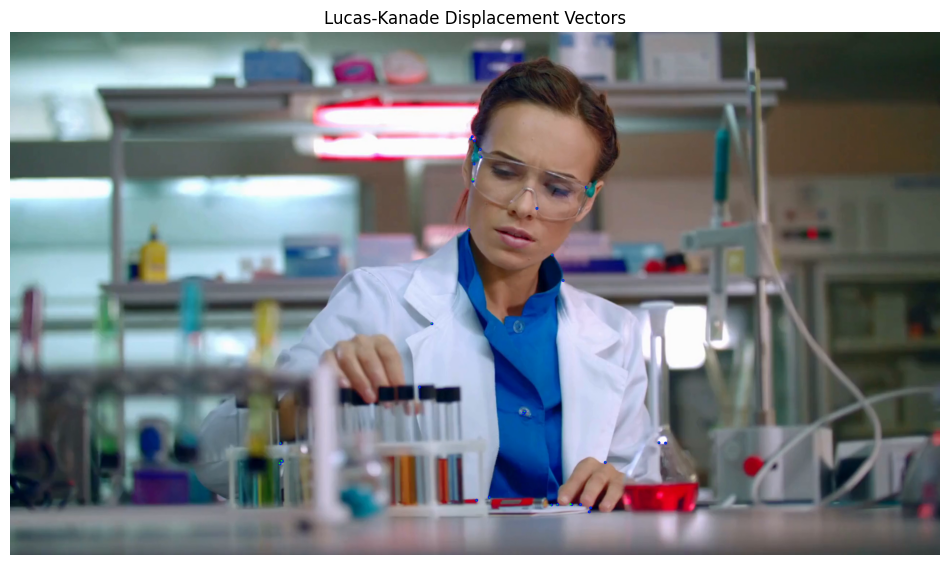

In [24]:
# Lucas-Kanade Displacement Vectors

cap = cv2.VideoCapture(video_path)

ret1, frame1 = cap.read()
ret2, frame2 = cap.read()

cap.release()

if not (ret1 and ret2):
    print("Error: Could not read two consecutive frames.")
else:
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    points1 = cv2.goodFeaturesToTrack(
        gray1,
        mask=None,
        **feature_params
    )

    points2, status, error = cv2.calcOpticalFlowPyrLK(
        gray1,
        gray2,
        points1,
        None,
        **lk_params
    )

    lk_result = frame2.copy()

    good_new = points2[status == 1]
    good_old = points1[status == 1]

    scale = 30

    for new, old in zip(good_new, good_old):

        x_new, y_new = new.ravel()
        x_old, y_old = old.ravel()

        dx = x_new - x_old
        dy = y_new - y_old

        cv2.circle(
            lk_result,
            (int(x_old), int(y_old)),
            4,
            (255, 0, 0),
            -1
        )

        end_x = int(x_old + dx * scale)
        end_y = int(y_old + dy * scale)

        cv2.arrowedLine(
            lk_result,
            (int(x_old), int(y_old)),
            (end_x, end_y),
            (0, 255, 0),
            2,
            tipLength=0.3
        )

    plt.figure(figsize=(12, 7))
    plt.imshow(
        cv2.cvtColor(lk_result, cv2.COLOR_BGR2RGB)
    )
    plt.title("Lucas-Kanade Displacement Vectors")
    plt.axis("off")
    plt.show()

In [20]:
# Farneback Dense Optical Flow

cap = cv2.VideoCapture(video_path)

ret1, frame1 = cap.read()
ret2, frame2 = cap.read()

cap.release()

if not (ret1 and ret2):
    print("Error: Could not read two consecutive frames.")
else:
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        gray1,
        gray2,
        None,
        pyr_scale=0.5,
        levels=3,
        winsize=15,
        iterations=3,
        poly_n=5,
        poly_sigma=1.2,
        flags=0
    )

    magnitude, angle = cv2.cartToPolar(
        flow[..., 0],
        flow[..., 1]
    )

    print("Farneback optical flow calculated.")
    print("Average motion magnitude:", np.mean(magnitude))
    print("Maximum motion magnitude:", np.max(magnitude))

Farneback optical flow calculated.
Average motion magnitude: 0.03133031
Maximum motion magnitude: 4.395469


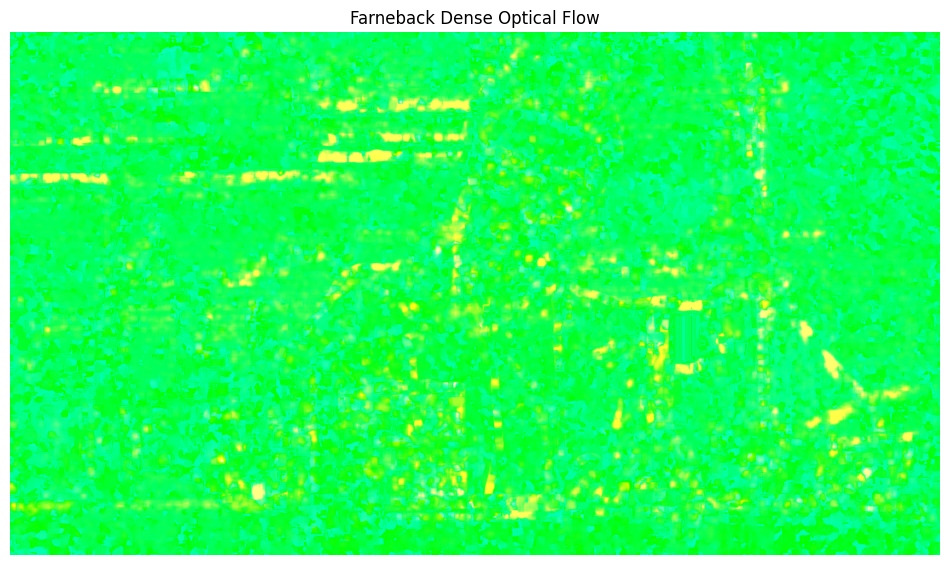

In [21]:
# Create HSV visualization

hsv = np.zeros_like(frame1)
hsv[..., 1] = 255

hsv[..., 0] = (
    angle * 180 / np.pi / 2
).astype(np.uint8)

max_mag = np.percentile(magnitude, 99)

if max_mag > 0:
    hsv[..., 2] = np.clip(
        (magnitude / max_mag) * 255,
        0,
        255
    ).astype(np.uint8)

farneback_visual = cv2.cvtColor(
    hsv,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 7))
plt.imshow(farneback_visual)
plt.title("Farneback Dense Optical Flow")
plt.axis("off")
plt.show()

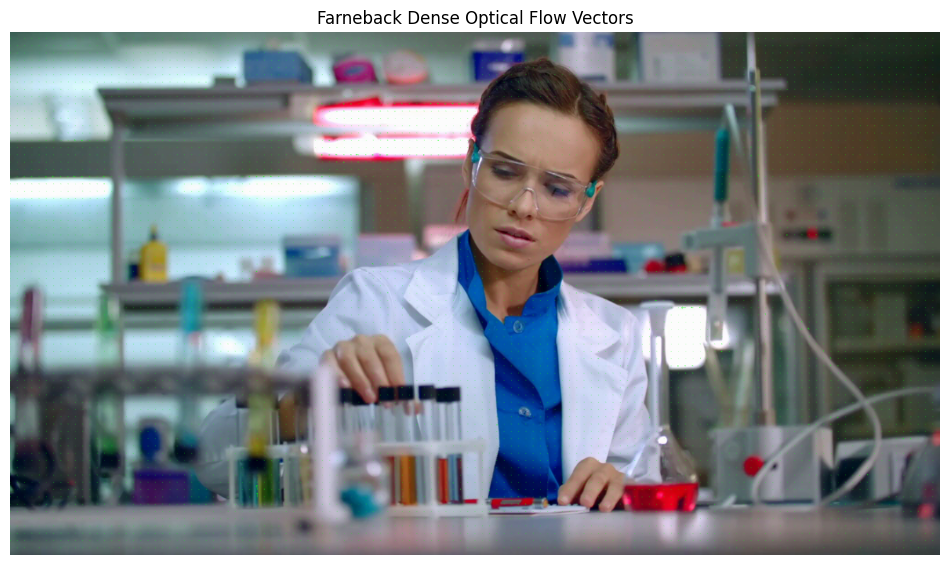

In [22]:
# Draw sampled Farneback motion vectors

vector_frame = frame2.copy()

step = 20

for y in range(0, gray2.shape[0], step):
    for x in range(0, gray2.shape[1], step):

        fx = flow[y, x, 0]
        fy = flow[y, x, 1]

        end_x = int(x + fx * 5)
        end_y = int(y + fy * 5)

        cv2.arrowedLine(
            vector_frame,
            (x, y),
            (end_x, end_y),
            (0, 255, 0),
            1,
            tipLength=0.3
        )

plt.figure(figsize=(12, 7))
plt.imshow(
    cv2.cvtColor(vector_frame, cv2.COLOR_BGR2RGB)
)
plt.title("Farneback Dense Optical Flow Vectors")
plt.axis("off")
plt.show()

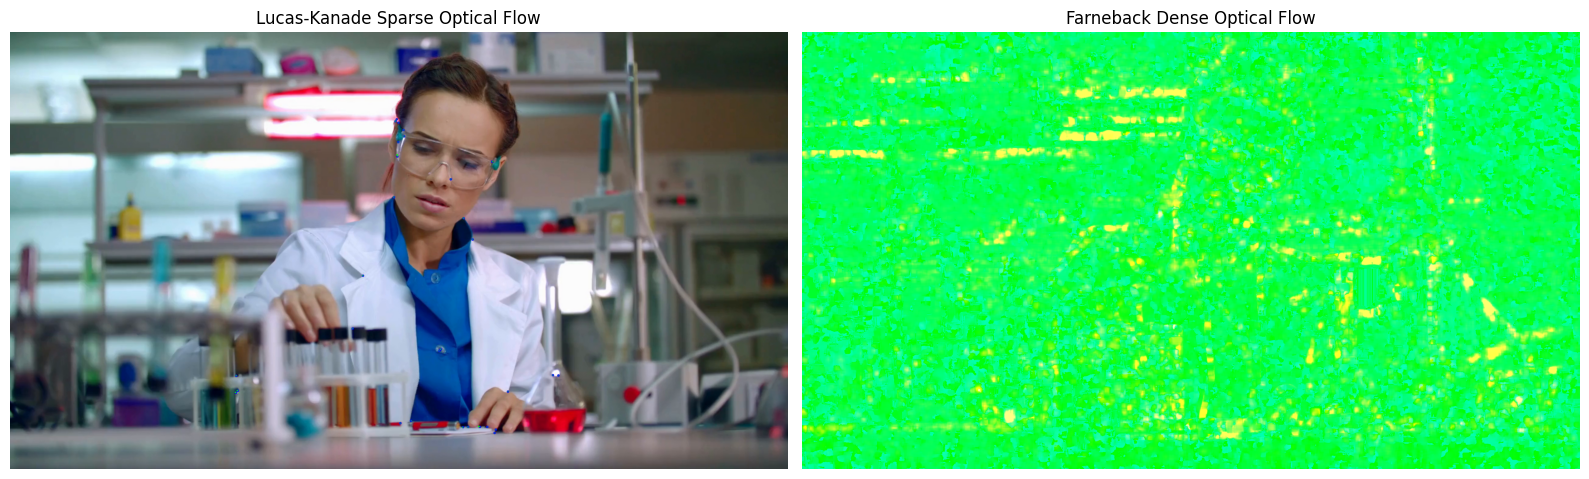

In [25]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(
    cv2.cvtColor(lk_result, cv2.COLOR_BGR2RGB)
)
plt.title("Lucas-Kanade Sparse Optical Flow")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(farneback_visual)
plt.title("Farneback Dense Optical Flow")
plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
# Lucas-Kanade average displacement
lk_average = np.mean(tracking_results)

# Farneback average magnitude
farneback_average = np.mean(magnitude)

print("Lucas-Kanade average displacement:",
      lk_average)

print("Farneback average motion magnitude:",
      farneback_average)

Lucas-Kanade average displacement: 2.5436907
Farneback average motion magnitude: 0.03133031


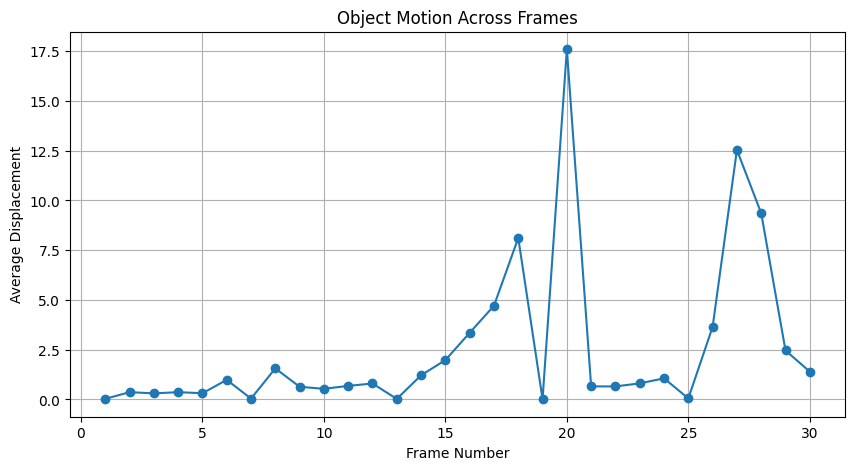

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(tracking_results) + 1),
    tracking_results,
    marker="o"
)

plt.title("Object Motion Across Frames")
plt.xlabel("Frame Number")
plt.ylabel("Average Displacement")
plt.grid(True)

plt.show()

## Observation

Lucas-Kanade Optical Flow successfully tracked selected feature points and generated motion trajectories and displacement vectors. Farneback Dense Optical Flow estimated motion over the entire image and provided a dense motion representation.

Lucas-Kanade produced sparse trajectories for selected feature points, while Farneback provided motion information across the image. The estimated motion varied according to object movement between consecutive frames.

The experiment demonstrates the use of optical flow for object tracking and motion analysis in video sequences.

# QUESTIONS
## 1. How does object tracking differ from object detection?

**Answer:**
Object detection identifies and locates objects in an image or video frame, while object tracking follows the movement of an already identified object across consecutive frames. Tracking focuses on maintaining the object's position and trajectory over time.

---

## 2. Explain how Optical Flow can be used for real-time object tracking.

**Answer:**
Optical Flow estimates the apparent motion of pixels between consecutive video frames. By tracking selected feature points and calculating their displacement, the movement and trajectory of an object can be estimated continuously. This allows objects to be tracked in real time without detecting them independently in every frame.

---

## 3. What is the role of Shi-Tomasi Corner Detection in the Lucas-Kanade Optical Flow algorithm?

**Answer:**
Shi-Tomasi Corner Detection identifies strong and easily trackable feature points in an image. These points are provided to the Lucas-Kanade algorithm, which tracks their movement across consecutive frames. Thus, Shi-Tomasi provides suitable feature points for sparse optical-flow tracking.

---

## 4. Why is Optical Flow suitable for motion analysis in videos?

**Answer:**
Optical Flow estimates the direction and magnitude of motion between consecutive frames. It provides information about object displacement, movement direction, speed, and trajectory. Therefore, it is useful for analyzing changing motion patterns in video sequences.

---

## 5. What challenges arise while tracking fast-moving or partially occluded objects?

**Answer:**
Fast-moving objects can move significantly between consecutive frames, making feature correspondence difficult. Partial occlusion can hide important feature points and cause tracking to fail. Other challenges include motion blur, lighting changes, low-texture regions, and sudden camera movement.

---

## 6. Compare Optical Flow-based tracking with deep learning-based object tracking methods.

**Answer:**

| Feature              | Optical Flow-based Tracking     | Deep Learning-based Tracking                         |
| -------------------- | ------------------------------- | ---------------------------------------------------- |
| Basic principle      | Tracks motion between frames    | Uses learned features to detect and track objects    |
| Computation          | Generally lower                 | Generally higher                                     |
| Training             | Does not require training data  | Usually requires training data                       |
| Tracking information | Based mainly on pixel motion    | Uses object appearance and learned features          |
| Performance          | Can work well for smooth motion | Can handle more complex object appearance and scenes |

Optical Flow is useful when motion information is sufficient, while deep learning methods can provide more advanced object-level tracking.

---

## 7. How can Optical Flow be used in traffic monitoring and autonomous driving systems?

**Answer:**
In traffic monitoring, Optical Flow can estimate the movement of vehicles and pedestrians and help analyze traffic patterns. In autonomous driving, it can provide information about the motion of surrounding objects and changes in the scene, supporting navigation and movement analysis.

---

## 8. Explain the effect of camera motion on Optical Flow estimation.

**Answer:**
Camera movement causes many or most image pixels to appear to move even when the objects themselves are stationary. This produces additional optical-flow vectors that can make object motion difficult to distinguish from camera motion. Therefore, camera movement can reduce the accuracy of motion estimation unless it is accounted for.

---

## 9. Mention five real-world applications where motion analysis using Optical Flow is commonly employed.

**Answer:**

1. Video surveillance
2. Traffic monitoring
3. Autonomous navigation
4. Sports analytics
5. Human activity recognition

---

## 10. How can Optical Flow improve the performance of surveillance, robotics, and human activity recognition systems?

**Answer:**
Optical Flow provides information about the direction and magnitude of movement in video. In **surveillance**, it helps detect and track moving objects. In **robotics**, it assists with motion estimation and navigation. In **human activity recognition**, it captures movement patterns of people and helps distinguish different activities.
